### Librabies ###

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV

from sklearn.metrics import (accuracy_score,f1_score,roc_auc_score,confusion_matrix,classification_report)

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
!pip install xgboost
from xgboost import XGBClassifier


from sklearn.model_selection import cross_val_score

import warnings
warnings.filterwarnings('ignore')

### Načítanie dátového súboru ###

In [2]:
TH = pd.read_csv(
    "classification/TomsHardware/Absolute_labeling/TomsHardware-Absolute-Sigma-500.data",
    sep=",",
    header=None
)


groups = [
    "NCD", "BL", "NAD", "AI", "NAC", "ND",
    "CS", "AT", "NA", "ADL", "AS_NA", "AS_NAC"
]

columns = []
for group in groups:
    for t in range(8):
        columns.append(f"{group}_{t}")

columns.append("label")  # остання колонка

TH.columns = columns


prefixes = {col.split("_")[0] for col in TH.columns if "_" in col}


TH.head()

,NCD_0,NCD_1,NCD_2,NCD_3,NCD_4,NCD_5,NCD_6,NCD_7,BL_0,BL_1,...,AS_NA_7,AS_NAC_0,AS_NAC_1,AS_NAC_2,AS_NAC_3,AS_NAC_4,AS_NAC_5,AS_NAC_6,AS_NAC_7,label
0,1,0,0,0,0,0,0,1,1.0,0.0,...,0.001816,0.001211,0.000560,0.000000,0.000000,0.000161,0.0,0.000301,0.000818,1.0
1,1,1,1,1,0,0,0,0,1.0,1.0,...,0.005029,0.000784,0.000802,0.001592,0.001612,0.000741,0.0,0.000545,0.002437,1.0
2,0,0,0,0,0,0,0,0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0
3,0,0,0,0,0,0,0,0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0
4,0,0,0,0,0,0,0,0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0


### Check if the data is balanced ###

Text(0.5, 1.0, "Class Distribution  Buzz -'0' Vs Non-Buzz - '1'")

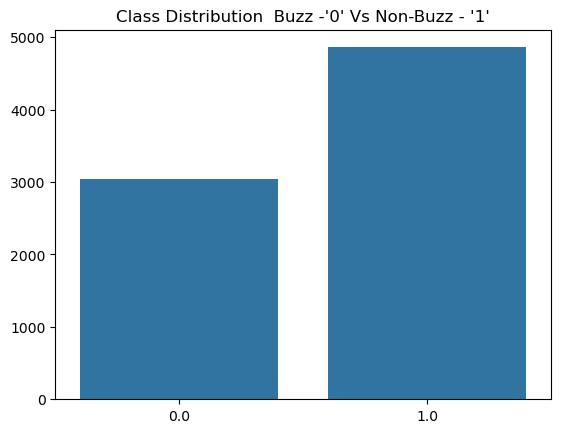

In [3]:
#print (TH['label'].value_counts())
sns.barplot(x = TH['label'].value_counts().index.values,y = TH['label'].value_counts().values)
plt.title("Class Distribution  Buzz -'0' Vs Non-Buzz - '1'")

The dataset shows a moderate class imbalance (approximately 61% non-buzz vs. 39% buzz).
This level of imbalance does not require explicit resampling techniques such as oversampling or undersampling.
Therefore, no resampling methods were applied, and model performance was evaluated using metrics robust to class imbalance, including F1-score and ROC-AUC, in addition to accuracy.

### Splitting the Dataset  and maybe scaling min max ###

In [47]:
X = TH.drop(columns=["label"])
y = TH["label"]

X_train, X_test, y_train, y_test = train_test_split( X, y,test_size=0.2,random_state=42,stratify=y)

### Dummy Classifier ###

In [5]:
dummy_majority = DummyClassifier(strategy='most_frequent').fit(X_train, y_train)
y_pred = dummy_majority.predict(X_test)


print("=== Dummy (Most Frequent) ===")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


=== Dummy (Most Frequent) ===
Accuracy: 0.6148007590132827
F1-score: 0.7614571092831962

Classification Report:

              precision    recall  f1-score   support

         0.0       0.00      0.00      0.00       609
         1.0       0.61      1.00      0.76       972

    accuracy                           0.61      1581
   macro avg       0.31      0.50      0.38      1581
weighted avg       0.38      0.61      0.47      1581



A DummyClassifier using the “most frequent” strategy was used as a baseline model.
The classifier achieved an accuracy of approximately 61.5%, which reflects the class distribution of the dataset.

### Logistic Regression ###

In [6]:
log_reg = LogisticRegression(max_iter=5000, solver="lbfgs")
log_reg.fit(X_train, y_train)

y_pred = log_reg.predict(X_test)


y_proba = log_reg.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)

print("=== Model 1: Logistic Regression (NO scaling) ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"F1-score:  {f1_score(y_test, y_pred):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_proba):.4f}\n")

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred), "\n")

print("Classification Report:")
print(classification_report(y_test, y_pred))


=== Model 1: Logistic Regression (NO scaling) ===
Accuracy: 0.9602
F1-score:  0.9675
ROC-AUC:   0.9947

Confusion Matrix:
[[580  29]
 [ 34 938]] 

Classification Report:
              precision    recall  f1-score   support

         0.0       0.94      0.95      0.95       609
         1.0       0.97      0.97      0.97       972

    accuracy                           0.96      1581
   macro avg       0.96      0.96      0.96      1581
weighted avg       0.96      0.96      0.96      1581



In [7]:
model_l1 = Pipeline([("scaler", StandardScaler()),("logistic", LogisticRegression(penalty="l1",solver="liblinear", max_iter=5000,C=1.0))])
model_l1.fit(X_train, y_train)

y_pred_l1 = model_l1.predict(X_test)
y_proba_l1 = model_l1.predict_proba(X_test)[:, 1]

acc_l1 = accuracy_score(y_test, y_pred_l1)
f1_l1 = f1_score(y_test, y_pred_l1)
auc_l1 = roc_auc_score(y_test, y_proba_l1)

print("=== Model 2: Logistic + L1 ===")
print(f"Accuracy: {acc_l1:.4f}")
print(f"F1-score:  {f1_l1:.4f}")
print(f"ROC-AUC:   {auc_l1:.4f}\n")

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_l1), "\n")

print("Classification Report:")
print(classification_report(y_test, y_pred_l1))


=== Model 2: Logistic + L1 ===
Accuracy: 0.8988
F1-score:  0.9136
ROC-AUC:   0.9758

Confusion Matrix:
[[575  34]
 [126 846]] 

Classification Report:
              precision    recall  f1-score   support

         0.0       0.82      0.94      0.88       609
         1.0       0.96      0.87      0.91       972

    accuracy                           0.90      1581
   macro avg       0.89      0.91      0.90      1581
weighted avg       0.91      0.90      0.90      1581



In [8]:
model_scaled = Pipeline([("scaler", StandardScaler()),("logistic", LogisticRegression(max_iter=5000, solver="lbfgs"))])

model_scaled.fit(X_train, y_train)


y_pred = model_scaled.predict(X_test)
y_proba = model_scaled.predict_proba(X_test)[:, 1]


acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)

print("=== Model 3: Logistic Regression + StandardScaler ===")
print(f"Accuracy: {acc:.4f}")
print(f"F1-score:  {f1:.4f}")
print(f"ROC-AUC:   {auc:.4f}\n")

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred), "\n")

print("Classification Report:")
print(classification_report(y_test, y_pred))


=== Model 3: Logistic Regression + StandardScaler ===
Accuracy: 0.9152
F1-score:  0.9283
ROC-AUC:   0.9823

Confusion Matrix:
[[579  30]
 [104 868]] 

Classification Report:
              precision    recall  f1-score   support

         0.0       0.85      0.95      0.90       609
         1.0       0.97      0.89      0.93       972

    accuracy                           0.92      1581
   macro avg       0.91      0.92      0.91      1581
weighted avg       0.92      0.92      0.92      1581



In [9]:
final_model = Pipeline([("scaler", StandardScaler()),("logistic", LogisticRegression(C=100,penalty="l2",solver="lbfgs",max_iter=5000))])
final_model.fit(X_train, y_train)

y_pred = final_model.predict(X_test)
y_proba = final_model.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)

print("=== Final Logistic Regression (Tuned) ===")
print(f"Accuracy: {acc:.4f}")
print(f"F1-score:  {f1:.4f}")
print(f"ROC-AUC:   {auc:.4f}\n")

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred), "\n")

print("Classification Report:")
print(classification_report(y_test, y_pred))


=== Final Logistic Regression (Tuned) ===
Accuracy: 0.9620
F1-score:  0.9688
ROC-AUC:   0.9951

Confusion Matrix:
[[588  21]
 [ 39 933]] 

Classification Report:
              precision    recall  f1-score   support

         0.0       0.94      0.97      0.95       609
         1.0       0.98      0.96      0.97       972

    accuracy                           0.96      1581
   macro avg       0.96      0.96      0.96      1581
weighted avg       0.96      0.96      0.96      1581



The baseline model without feature scaling achieved an accuracy of 96.1%, an F1-score of 96.8%, and a ROC-AUC of 99.5%, indicating strong separability in the dataset.

After applying StandardScaler, performance slightly decreased to an accuracy of 91.5%, an F1-score of 92.8%, and a ROC-AUC of 98.2%, while maintaining balanced recall across both classes.

Logistic Regression with L1 regularization achieved an accuracy of 89.7%, an F1-score of 91.2%, and a ROC-AUC of 97.6%, reflecting the trade-off between sparsity and predictive performance.

The tuned Logistic Regression model with L2 regularization achieved the best overall performance, with an accuracy of 96.2%, an F1-score of 96.9%, and a ROC-AUC of 99.5%, and was selected as the final linear model.


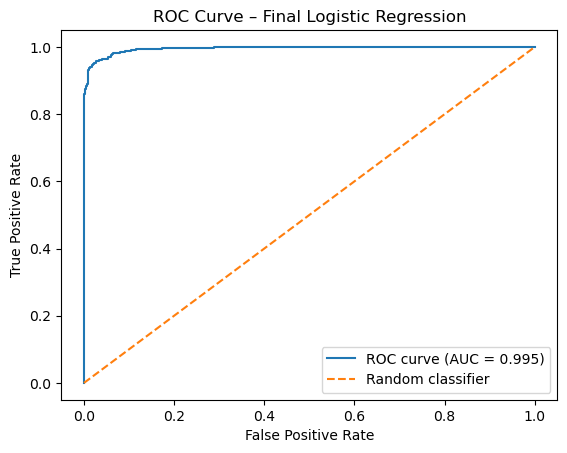

In [14]:
from sklearn.metrics import roc_curve, auc

# Ймовірності для позитивного класу
y_proba = final_model.predict_proba(X_test)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Final Logistic Regression")
plt.legend()
plt.show()

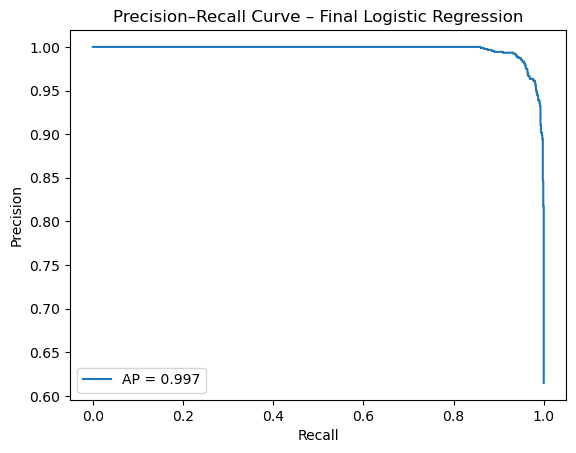

In [9]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, _ = precision_recall_curve(y_test, y_proba)
ap = average_precision_score(y_test, y_proba)

plt.figure()
plt.plot(recall, precision, label=f"AP = {ap:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve – Final Logistic Regression")
plt.legend()
plt.show()

The ROC curve demonstrates the strong ability of the final Logistic Regression model to distinguish between Buzz and Non-Buzz classes, as reflected by a high ROC-AUC value of 0.995.
The Precision–Recall curve highlights the model’s effectiveness in identifying the Buzz class, maintaining high precision across a wide range of recall values, with an average precision of 0.997.

### Decision Tree ###

In [10]:
tree_model = DecisionTreeClassifier(random_state=42, max_depth=5)

tree_model.fit(X_train, y_train)

y_pred = tree_model.predict(X_test)
y_proba = tree_model.predict_proba(X_test)[:, 1]

print("=== Decision Tree (Default) ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"F1-score:  {f1_score(y_test, y_pred):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_proba):.4f}\n")

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred), "\n")

print("Classification Report:")
print(classification_report(y_test, y_pred))


=== Decision Tree (Default) ===
Accuracy: 0.9646
F1-score:  0.9709
ROC-AUC:   0.9875

Confusion Matrix:
[[590  19]
 [ 37 935]] 

Classification Report:
              precision    recall  f1-score   support

         0.0       0.94      0.97      0.95       609
         1.0       0.98      0.96      0.97       972

    accuracy                           0.96      1581
   macro avg       0.96      0.97      0.96      1581
weighted avg       0.97      0.96      0.96      1581



In [11]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


tree_cv_model = DecisionTreeClassifier(random_state=42,max_depth=5)

cv_f1 = cross_val_score(tree_cv_model, X_train, y_train, cv=cv, scoring="f1", n_jobs=-1)

print("=== Decision Tree (max_depth=5) - 5fold CV (train only) ===")
print(f"F1 mean: {cv_f1.mean():.4f}")
print(f"F1 std:  {cv_f1.std():.4f}\n")

tree_cv_model.fit(X_train, y_train)
y_pred = tree_cv_model.predict(X_test)
y_proba = tree_cv_model.predict_proba(X_test)[:, 1]

print("=== Decision Tree (max_depth=5) - Test ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"F1-score:  {f1_score(y_test, y_pred):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_proba):.4f}\n")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred), "\n")
print("Classification Report:")
print(classification_report(y_test, y_pred))


=== Decision Tree (max_depth=5) - 5fold CV (train only) ===
F1 mean: 0.9714
F1 std:  0.0055

=== Decision Tree (max_depth=5) - Test ===
Accuracy: 0.9646
F1-score:  0.9709
ROC-AUC:   0.9875

Confusion Matrix:
[[590  19]
 [ 37 935]] 

Classification Report:
              precision    recall  f1-score   support

         0.0       0.94      0.97      0.95       609
         1.0       0.98      0.96      0.97       972

    accuracy                           0.96      1581
   macro avg       0.96      0.97      0.96      1581
weighted avg       0.97      0.96      0.96      1581



In [12]:
balanced_tree = DecisionTreeClassifier(random_state=42,max_depth=5,class_weight="balanced")
balanced_tree.fit(X_train, y_train)

y_pred_bal = balanced_tree.predict(X_test)
y_proba_bal = balanced_tree.predict_proba(X_test)[:, 1]

print("=== Balanced Decision Tree (no CV) ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_bal):.4f}")
print(f"F1-score:  {f1_score(y_test, y_pred_bal):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_proba_bal):.4f}\n")

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_bal), "\n")

print("Classification Report:")
print(classification_report(y_test, y_pred_bal))

=== Balanced Decision Tree (no CV) ===
Accuracy: 0.9639
F1-score:  0.9704
ROC-AUC:   0.9867

Confusion Matrix:
[[589  20]
 [ 37 935]] 

Classification Report:
              precision    recall  f1-score   support

         0.0       0.94      0.97      0.95       609
         1.0       0.98      0.96      0.97       972

    accuracy                           0.96      1581
   macro avg       0.96      0.96      0.96      1581
weighted avg       0.96      0.96      0.96      1581



### Random Forest ###

In [13]:
rf = RandomForestClassifier(n_estimators=300,random_state=42,n_jobs=-1)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)[:, 1]

print("=== Random Forest (baseline) ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"F1-score:  {f1_score(y_test, y_pred):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_proba):.4f}\n")

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred), "\n")

print("Classification Report:")
print(classification_report(y_test, y_pred))

=== Random Forest (baseline) ===
Accuracy: 0.9696
F1-score:  0.9752
ROC-AUC:   0.9957

Confusion Matrix:
[[588  21]
 [ 27 945]] 

Classification Report:
              precision    recall  f1-score   support

         0.0       0.96      0.97      0.96       609
         1.0       0.98      0.97      0.98       972

    accuracy                           0.97      1581
   macro avg       0.97      0.97      0.97      1581
weighted avg       0.97      0.97      0.97      1581



In [60]:
rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)

param_grid = {
    "n_estimators": [200, 500],
    "max_depth": [None, 5, 10],
    "min_samples_leaf": [1, 5, 10],
    "max_features": ["sqrt", 0.5]
}

grid = GridSearchCV(rf_base, param_grid, cv=5, scoring="f1", n_jobs=-1)
grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
print("Best CV F1:", grid.best_score_)

best_rf = grid.best_estimator_

Best params: {'max_depth': None, 'max_features': 0.5, 'min_samples_leaf': 1, 'n_estimators': 200}
Best CV F1: 0.9776531328254899


### SVM ###

In [22]:
svm_linear = Pipeline([("scaler", StandardScaler()),("svm", SVC(kernel="linear", C=1.0, probability=True, random_state=42))])
svm_linear.fit(X_train, y_train)

y_pred = svm_linear.predict(X_test)
y_proba = svm_linear.predict_proba(X_test)[:, 1]

print("=== SVM (Linear) ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"F1-score:  {f1_score(y_test, y_pred):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_proba):.4f}\n")

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred), "\n")

print("Classification Report:")
print(classification_report(y_test, y_pred))

=== SVM (Linear) ===
Accuracy: 0.9342
F1-score:  0.9450
ROC-AUC:   0.9886

Confusion Matrix:
[[583  26]
 [ 78 894]] 

Classification Report:
              precision    recall  f1-score   support

         0.0       0.88      0.96      0.92       609
         1.0       0.97      0.92      0.95       972

    accuracy                           0.93      1581
   macro avg       0.93      0.94      0.93      1581
weighted avg       0.94      0.93      0.93      1581



In [23]:
svm_rbf = Pipeline([("scaler", StandardScaler()),("svm", SVC(kernel="rbf", C=1.0, gamma="scale", probability=True, random_state=42))])

svm_rbf.fit(X_train, y_train)

y_pred = svm_rbf.predict(X_test)
y_proba = svm_rbf.predict_proba(X_test)[:, 1]

print("=== SVM (RBF) ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"F1-score:  {f1_score(y_test, y_pred):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_proba):.4f}\n")

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred), "\n")

print("Classification Report:")
print(classification_report(y_test, y_pred))

=== SVM (RBF) ===
Accuracy: 0.8533
F1-score:  0.8762
ROC-AUC:   0.9475

Confusion Matrix:
[[528  81]
 [151 821]] 

Classification Report:
              precision    recall  f1-score   support

         0.0       0.78      0.87      0.82       609
         1.0       0.91      0.84      0.88       972

    accuracy                           0.85      1581
   macro avg       0.84      0.86      0.85      1581
weighted avg       0.86      0.85      0.85      1581



### Choose Top 5 features ###

In [48]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, classification_report

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    use_label_encoder=False,
    eval_metric="logloss"
)

xgb.fit(X_train, y_train)

y_pred = xgb.predict(X_test)
y_proba = xgb.predict_proba(X_test)[:, 1]

print("=== XGBoost (Base) ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"F1-score:  {f1_score(y_test, y_pred):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_proba):.4f}\n")

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred), "\n")

print("Classification Report:")
print(classification_report(y_test, y_pred))

=== XGBoost (Base) ===
Accuracy: 0.9709
F1-score:  0.9762
ROC-AUC:   0.9965

Confusion Matrix:
[[590  19]
 [ 27 945]] 

Classification Report:
              precision    recall  f1-score   support

         0.0       0.96      0.97      0.96       609
         1.0       0.98      0.97      0.98       972

    accuracy                           0.97      1581
   macro avg       0.97      0.97      0.97      1581
weighted avg       0.97      0.97      0.97      1581



In [50]:
importances = xgb.feature_importances_
importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": importances
})
importance_df["base_feature"] = importance_df["feature"].str[:-2]
grouped_importance = (importance_df.groupby("base_feature")["importance"].sum().sort_values(ascending=False))

top5 = grouped_importance.head(5)
print(top5)

base_feature
ND     0.466495
NCD    0.064387
BL     0.060348
NAC    0.058365
NAD    0.054535
Name: importance, dtype: float32


In [52]:
selected_base = top5.index.tolist()

selected_columns = [
    col for col in X.columns
    if col.split("_")[0] in selected_base
]

X_top5 = X[selected_columns]

print(X_top5.shape)
X_top5.head(2)

(7905, 40)


,NCD_0,NCD_1,NCD_2,NCD_3,NCD_4,NCD_5,NCD_6,NCD_7,BL_0,BL_1,...,NAC_6,NAC_7,ND_0,ND_1,ND_2,ND_3,ND_4,ND_5,ND_6,ND_7
0,1,0,0,0,0,0,0,1,1.0,0.0,...,2,6,1001,1108,869,680,802,811,1044,1309
1,1,1,1,1,0,0,0,0,1.0,1.0,...,4,15,5592,4765,4982,4392,4091,5037,6835,6727


In [53]:
from sklearn.model_selection import train_test_split

X_train_top, X_test_top, y_train_top, y_test_top = train_test_split(X_top5,y,test_size=0.2,random_state=42,stratify=y)

### XGBoost for top 5 ###

In [54]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report, confusion_matrix

xgb = XGBClassifier(random_state=42,use_label_encoder=False,eval_metric="logloss")

param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

grid_search = GridSearchCV(estimator=xgb,param_grid=param_grid,scoring="f1",cv=5,n_jobs=-1,verbose=1)

grid_search.fit(X_train_top, y_train_top)
print("Best parameters:")
print(grid_search.best_params_)
best_xgb = grid_search.best_estimator_


y_pred = best_xgb.predict(X_test_top)
y_proba = best_xgb.predict_proba(X_test_top)[:, 1]

print("=== XGBoost (Top 5 Features + GridSearch) ===")

print(f"Accuracy: {accuracy_score(y_test_top, y_pred):.4f}")
print(f"F1-score: {f1_score(y_test_top, y_pred):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test_top, y_proba):.4f}\n")

print("Confusion Matrix:")
print(confusion_matrix(y_test_top, y_pred), "\n")

print("Classification Report:")
print(classification_report(y_test_top, y_pred))

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best parameters:
{'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}
=== XGBoost (Top 5 Features + GridSearch) ===
Accuracy: 0.9690
F1-score: 0.9747
ROC-AUC: 0.9962

Confusion Matrix:
[[587  22]
 [ 27 945]] 

Classification Report:
              precision    recall  f1-score   support

         0.0       0.96      0.96      0.96       609
         1.0       0.98      0.97      0.97       972

    accuracy                           0.97      1581
   macro avg       0.97      0.97      0.97      1581
weighted avg       0.97      0.97      0.97      1581



### Random Forest for top 5 ###

In [55]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, classification_report

In [62]:
rf = RandomForestClassifier( random_state=42)
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
    "max_features": ["sqrt", "log2"]
}

grid_search_rf = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1,
    verbose=1
)
grid_search_rf.fit(X_train_top, y_train_top)
print("Best parameters:")
print(grid_search_rf.best_params_)

best_rf = grid_search_rf.best_estimator_

y_pred = best_rf.predict(X_test_top)
y_proba = best_rf.predict_proba(X_test_top)[:, 1]

print("=== Random Forest (Top 5 Features + GridSearch) ===")

print(f"Accuracy: {accuracy_score(y_test_top, y_pred):.4f}")
print(f"F1-score: {f1_score(y_test_top, y_pred):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test_top, y_proba):.4f}\n")

print("Confusion Matrix:")
print(confusion_matrix(y_test_top, y_pred), "\n")

print("Classification Report:")
print(classification_report(y_test_top, y_pred))

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best parameters:
{'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
=== Random Forest (Top 5 Features + GridSearch) ===
Accuracy: 0.9690
F1-score: 0.9747
ROC-AUC: 0.9961

Confusion Matrix:
[[589  20]
 [ 29 943]] 

Classification Report:
              precision    recall  f1-score   support

         0.0       0.95      0.97      0.96       609
         1.0       0.98      0.97      0.97       972

    accuracy                           0.97      1581
   macro avg       0.97      0.97      0.97      1581
weighted avg       0.97      0.97      0.97      1581



In [57]:
pip install lightgbm

   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 1.5/1.5 MB 51.3 MB/s  0:00:00
Note: you may need to restart the kernel to use updated packages.


In [58]:
from lightgbm import LGBMClassifier

lgb = LGBMClassifier(random_state=42)

param_grid = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [-1, 5, 10],
    "num_leaves": [31, 50],
    "subsample": [0.8, 1.0]
}

grid_search_lgb = GridSearchCV(
    estimator=lgb,
    param_grid=param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_search_lgb.fit(X_train_top, y_train_top)

print("Best parameters:")
print(grid_search_lgb.best_params_)

best_lgb = grid_search_lgb.best_estimator_

y_pred = best_lgb.predict(X_test_top)
y_proba = best_lgb.predict_proba(X_test_top)[:,1]

print("=== LightGBM (Top 5 Features + GridSearch) ===")

print(f"Accuracy: {accuracy_score(y_test_top, y_pred):.4f}")
print(f"F1-score: {f1_score(y_test_top, y_pred):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test_top, y_proba):.4f}\n")

print("Confusion Matrix:")
print(confusion_matrix(y_test_top, y_pred), "\n")

print("Classification Report:")
print(classification_report(y_test_top, y_pred))

Fitting 5 folds for each of 108 candidates, totalling 540 fits
[LightGBM] [Info] Number of positive: 3888, number of negative: 2436
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000805 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5766
[LightGBM] [Info] Number of data points in the train set: 6324, number of used features: 40
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.614801 -> initscore=0.467538
[LightGBM] [Info] Start training from score 0.467538
Best parameters:
{'learning_rate': 0.05, 'max_depth': 10, 'n_estimators': 300, 'num_leaves': 31, 'subsample': 0.8}
=== LightGBM (Top 5 Features + GridSearch) ===
Accuracy: 0.9696
F1-score: 0.9752
ROC-AUC: 0.9959

Confusion Matrix:
[[588  21]
 [ 27 945]] 

Classification Report:
              precision    recall  f1-score   support

         0.0       0.96      0.97      0.96       

### stacking ensemble ###

In [63]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

stack_model = StackingClassifier(
    estimators=[
        ("rf", best_rf),
        ("xgb", best_xgb),
        ("lgb", best_lgb)
    ],
    final_estimator=LogisticRegression(),
    n_jobs=-1
)

stack_model.fit(X_train_top, y_train_top)

y_pred = stack_model.predict(X_test_top)
y_proba = stack_model.predict_proba(X_test_top)[:,1]

print("=== Stacking Ensemble ===")

print(f"Accuracy: {accuracy_score(y_test_top, y_pred):.4f}")
print(f"F1-score: {f1_score(y_test_top, y_pred):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test_top, y_proba):.4f}\n")

print("Confusion Matrix:")
print(confusion_matrix(y_test_top, y_pred), "\n")

print("Classification Report:")
print(classification_report(y_test_top, y_pred))

=== Stacking Ensemble ===
Accuracy: 0.9684
F1-score: 0.9742
ROC-AUC: 0.9963

Confusion Matrix:
[[587  22]
 [ 28 944]] 

Classification Report:
              precision    recall  f1-score   support

         0.0       0.95      0.96      0.96       609
         1.0       0.98      0.97      0.97       972

    accuracy                           0.97      1581
   macro avg       0.97      0.97      0.97      1581
weighted avg       0.97      0.97      0.97      1581



### Result ###

In [1]:
import pandas as pd

results = pd.DataFrame({
    "Model": [
        "XGBoost (Top-5)",
        "Random Forest (Top-5)",
        "LightGBM (Top-5)",
        "Stacking Ensemble"
    ],
    
    "Best Parameters": [
        "{colsample_bytree:1.0, learning_rate:0.1, max_depth:5, n_estimators:200, subsample:0.8}",
        "{max_depth:None, max_features:sqrt, min_samples_leaf:1, min_samples_split:5, n_estimators:200}",
        "{learning_rate:0.05, max_depth:10, n_estimators:300, num_leaves:31, subsample:0.8}",
        "RF + XGB + LGB (LogisticRegression)"
    ],
    
    "Accuracy": [
        0.9690,
        0.9690,
        0.9696,
        0.9684
    ],
    
    "F1-score": [
        0.9747,
        0.9747,
        0.9752,
        0.9742
    ],
    
    "ROC-AUC": [
        0.9962,
        0.9961,
        0.9959,
        0.9963
    ]
})

results.round(4)

,Model,Best Parameters,Accuracy,F1-score,ROC-AUC
0,XGBoost (Top-5),"{colsample_bytree:1.0, learning_rate:0.1, max_...",0.9690,0.9747,0.9962
1,Random Forest (Top-5),"{max_depth:None, max_features:sqrt, min_sample...",0.9690,0.9747,0.9961
2,LightGBM (Top-5),"{learning_rate:0.05, max_depth:10, n_estimator...",0.9696,0.9752,0.9959
3,Stacking Ensemble,RF + XGB + LGB (LogisticRegression),0.9684,0.9742,0.9963


In [16]:
import pandas as pd

results = [
    {
        "Model": "Logistic Regression (GridSearch)",
        "F1": 0.969,
        "Recall": 0.96,
        "Precision": 0.98,
        "ROC-AUC": 0.995
    },
    {
        "Model": "Decision Tree",
        "F1": 0.971,
        "Recall": 0.97,
        "Precision": 0.98,
        "ROC-AUC": 0.988
    },
    {
        "Model": "Random Forest",
        "F1": 0.975,
        "Recall": 0.97,
        "Precision": 0.98,
        "ROC-AUC": 0.996
    },
    {
        "Model": "XGBoost",
        "F1": 0.976,
        "Recall": 0.97,
        "Precision": 0.98,
        "ROC-AUC": 0.997
    },
    {
        "Model": "SVM (Linear)",
        "F1": 0.95,
        "Recall": 0.92,
        "Precision": 0.97,
        "ROC-AUC": 0.989
    }
]

df_results = pd.DataFrame(results)

# сортуємо за F1-score
df_results = df_results.sort_values(by="F1", ascending=False).reset_index(drop=True)

df_results

,Model,F1,Recall,Precision,ROC-AUC
0,XGBoost,0.976,0.97,0.98,0.997
1,Random Forest,0.975,0.97,0.98,0.996
2,Decision Tree,0.971,0.97,0.98,0.988
3,Logistic Regression (GridSearch),0.969,0.96,0.98,0.995
4,SVM (Linear),0.950,0.92,0.97,0.989


### Neural Network ###

In [7]:
!pip install tensorflow

   ---------------------------------------- 0.0/332.0 MB ? eta -:--:--
   - -------------------------------------- 16.5/332.0 MB 81.4 MB/s eta 0:00:04
   --- ------------------------------------ 28.3/332.0 MB 69.6 MB/s eta 0:00:05
   ----- ---------------------------------- 42.7/332.0 MB 70.4 MB/s eta 0:00:05
   ------- -------------------------------- 58.2/332.0 MB 71.7 MB/s eta 0:00:04
   --------- ------------------------------ 74.7/332.0 MB 73.5 MB/s eta 0:00:04
   ----------- ---------------------------- 92.0/332.0 MB 75.1 MB/s eta 0:00:04
   ------------ -------------------------- 109.3/332.0 MB 76.4 MB/s eta 0:00:03
   -------------- ------------------------ 126.9/332.0 MB 77.6 MB/s eta 0:00:03
   ---------------- ---------------------- 144.7/332.0 MB 78.7 MB/s eta 0:00:03
   ------------------- ------------------- 162.3/332.0 MB 79.2 MB/s eta 0:00:03
   --------------------- ----------------- 181.1/332.0 MB 80.4 MB/s eta 0:00:02
   ----------------------- --------------- 200.8/

In [5]:
X = TH.drop('label', axis=1)
y = TH['label']

X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=42,stratify=y)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [8]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
model = Sequential()

model.add(Dense(64, activation='relu', input_shape=(96,)))
model.add(Dense(32, activation='relu'))
model.add(Dense(1, activation='sigmoid'))


In [9]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [10]:
history = model.fit(X_train,y_train,epochs=30,batch_size=32,validation_split=0.2)

Epoch 1/30
159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8061 - loss: 0.4278 - val_accuracy: 0.8308 - val_loss: 0.3880
Epoch 2/30
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8508 - loss: 0.3478 - val_accuracy: 0.8427 - val_loss: 0.3592
Epoch 3/30
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8630 - loss: 0.3190 - val_accuracy: 0.8498 - val_loss: 0.3382
Epoch 4/30
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8701 - loss: 0.2939 - val_accuracy: 0.8632 - val_loss: 0.3317
Epoch 5/30
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8784 - loss: 0.2746 - val_accuracy: 0.8870 - val_loss: 0.3289
Epoch 6/30
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8828 - loss: 0.2566 - val_accuracy: 0.8735 - val_loss: 0.2937
Epoch 7/30
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8972 - loss: 0.2388 - val_accuracy: 0.8909 - val_loss: 0.2798
Epoch 8/30
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9027 - loss: 0.2214 - val_accuracy: 0.

In [11]:
loss, accuracy = model.evaluate(X_test, y_test)
print("Test accuracy:", accuracy)

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9007 - loss: 0.3344
Test accuracy: 0.9006957411766052


In [14]:
y_prob = model.predict(X_test).ravel()
y_pred = (y_prob >= 0.5).astype(int)

from sklearn.metrics import classification_report, f1_score, confusion_matrix

print("F1:", f1_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
F1: 0.9235265465172917
[[476 133]
 [ 24 948]]
              precision    recall  f1-score   support

         0.0       0.95      0.78      0.86       609
         1.0       0.88      0.98      0.92       972

    accuracy                           0.90      1581
   macro avg       0.91      0.88      0.89      1581
weighted avg       0.91      0.90      0.90      1581



In [13]:
from sklearn.metrics import confusion_matrix, classification_report

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[476 133]
 [ 24 948]]
              precision    recall  f1-score   support

         0.0       0.95      0.78      0.86       609
         1.0       0.88      0.98      0.92       972

    accuracy                           0.90      1581
   macro avg       0.91      0.88      0.89      1581
weighted avg       0.91      0.90      0.90      1581



In [32]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

In [33]:
model = Sequential()

model.add(Dense(128, activation='relu', input_shape=(96,)))
model.add(BatchNormalization())
model.add(Dropout(0.3))

model.add(Dense(64, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.3))

model.add(Dense(32, activation='relu'))

model.add(Dense(1, activation='sigmoid'))

In [34]:
optimizer = Adam(learning_rate=0.0005)

model.compile(
    optimizer=optimizer,
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [35]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

In [42]:
history = model.fit(X_train,y_train,epochs=200,batch_size=32,validation_split=0.2)

Epoch 1/200
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9658 - loss: 0.0919 - val_accuracy: 0.9502 - val_loss: 0.1625
Epoch 2/200
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9668 - loss: 0.0848 - val_accuracy: 0.9407 - val_loss: 0.1707
Epoch 3/200
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9674 - loss: 0.0839 - val_accuracy: 0.9447 - val_loss: 0.1767
Epoch 4/200
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9652 - loss: 0.0876 - val_accuracy: 0.9415 - val_loss: 0.1743
Epoch 5/200
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9694 - loss: 0.0881 - val_accuracy: 0.9462 - val_loss: 0.1500
Epoch 6/200
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9662 - loss: 0.0856 - val_accuracy: 0.9312 - val_loss: 0.1913
Epoch 7/200
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9735 - loss: 0.0777 - val_accuracy: 0.9423 - val_loss: 0.1759
Epoch 8/200
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9707 - loss: 0.0778 - val_accu

In [40]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test accuracy:", accuracy)


50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9431 - loss: 0.1614 
Test accuracy: 0.9430739879608154


In [43]:
import numpy as np
from sklearn.metrics import f1_score

thresholds = np.linspace(0.05, 0.95, 19)
best_t, best_f1 = 0.5, -1

for t in thresholds:
    y_pred_t = (y_prob >= t).astype(int)
    f1 = f1_score(y_test, y_pred_t)
    if f1 > best_f1:
        best_f1 = f1
        best_t = t

print("Best threshold:", best_t)
print("Best F1:", best_f1)

Best threshold: 0.3
Best F1: 0.9597554763117677


In [44]:
y_prob = model.predict(X_test).ravel()
y_pred = (y_prob >= 0.5).astype(int)

from sklearn.metrics import classification_report, f1_score, confusion_matrix

print("F1:", f1_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 979us/step
F1: 0.9534883720930233
[[546  63]
 [ 29 943]]
              precision    recall  f1-score   support

         0.0       0.95      0.90      0.92       609
         1.0       0.94      0.97      0.95       972

    accuracy                           0.94      1581
   macro avg       0.94      0.93      0.94      1581
weighted avg       0.94      0.94      0.94      1581



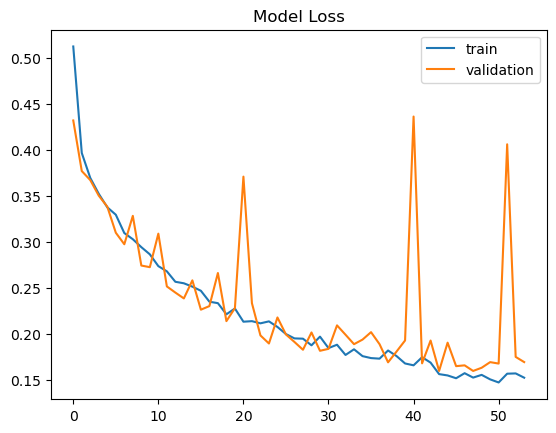

In [22]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='validation')
plt.legend()
plt.title("Model Loss")
plt.show()

In [24]:
X_train_cnn = X_train.reshape(-1, 8, 12)
X_test_cnn = X_test.reshape(-1, 8, 12)


In [25]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [26]:
model = Sequential()

model.add(Conv1D(64, kernel_size=2, activation='relu', input_shape=(8,12)))
model.add(MaxPooling1D(pool_size=2))

model.add(Conv1D(32, kernel_size=2, activation='relu'))

model.add(Flatten())

model.add(Dense(64, activation='relu'))
model.add(Dropout(0.3))

model.add(Dense(1, activation='sigmoid'))

In [27]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [28]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

In [29]:
history = model.fit(
    X_train_cnn,
    y_train,
    epochs=200,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop]
)

Epoch 1/200
159/159 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8225 - loss: 0.4109 - val_accuracy: 0.8435 - val_loss: 0.3867
Epoch 2/200
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8599 - loss: 0.3377 - val_accuracy: 0.8656 - val_loss: 0.3282
Epoch 3/200
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8715 - loss: 0.3002 - val_accuracy: 0.8783 - val_loss: 0.2924
Epoch 4/200
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8915 - loss: 0.2615 - val_accuracy: 0.8996 - val_loss: 0.2695
Epoch 5/200
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9027 - loss: 0.2363 - val_accuracy: 0.9083 - val_loss: 0.2456
Epoch 6/200
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9114 - loss: 0.2127 - val_accuracy: 0.9115 - val_loss: 0.2253
Epoch 7/200
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9186 - loss: 0.1977 - val_accuracy: 0.9170 - val_loss: 0.2130
Epoch 8/200
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9261 - loss: 0.1803 - val_accu

In [30]:
loss, accuracy = model.evaluate(X_test_cnn, y_test)

print("Test accuracy:", accuracy)

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9273 - loss: 0.1925
Test accuracy: 0.927261233329773


In [31]:
y_prob = model.predict(X_test_cnn).ravel()
y_pred = (y_prob >= 0.5).astype(int)

from sklearn.metrics import classification_report, f1_score

print("F1:", f1_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
F1: 0.9416539827498731
              precision    recall  f1-score   support

         0.0       0.92      0.88      0.90       609
         1.0       0.93      0.95      0.94       972

    accuracy                           0.93      1581
   macro avg       0.93      0.92      0.92      1581
weighted avg       0.93      0.93      0.93      1581



In [2]:
import pandas as pd

nn_results = pd.DataFrame({
    "Model": [
        "Neural Network (Simple)",
        "Neural Network (Improved)",
        "CNN (Convolutional Neural Network)"
    ],
    
    "Architecture": [
        "Dense(64) → Dense(32) → Dense(1)",
        "Dense(128) → BatchNorm → Dropout → Dense(64) → BatchNorm → Dropout → Dense(32) → Dense(1)",
        "Conv1D(64) → MaxPooling → Conv1D(32) → Flatten → Dense(64) → Dropout → Dense(1)"
    ],
    
    "Epochs": [
        30,
        200,
        200
    ],
    
    "Batch Size": [
        32,
        32,
        32
    ],
    
    "Accuracy": [
        0.90,
        0.94,
        0.927
    ],
    
    "F1-score": [
        0.92,
        0.953,
        0.942
    ]
})

nn_results.round(3)

,Model,Architecture,Epochs,Batch Size,Accuracy,F1-score
0,Neural Network (Simple),Dense(64) → Dense(32) → Dense(1),30,32,0.900,0.920
1,Neural Network (Improved),Dense(128) → BatchNorm → Dropout → Dense(64) →...,200,32,0.940,0.953
2,CNN (Convolutional Neural Network),Conv1D(64) → MaxPooling → Conv1D(32) → Flatten...,200,32,0.927,0.942
